# **Stochastic Computational Modeling**


In [2]:
# Install necessary libraries (uncomment if needed)
!pip install numpy scipy matplotlib

# **Question 1:**

# **Question 1(a):  Calculating $x$**
In a stochastic matrix, the sum of each row should be 1 since it provides a full probability distribution of the subsequent state.For the third row (State C):$$0.16 + 0.16 + 0.22 + x + 0.26 = 1.0$$$$0.80 + x = 1.0 \implies x = 0.20$$

**Explanation:**
This property is a fundamental requirement because the system must transition to some state within the defined state space. If the sum were less than 1, probability would "disappear"; if it were greater than 1, it would imply a >100% chance of an event occurring.


In [3]:
# Known probabilities in row 3
values = [0.16, 0.16, 0.22, 0.26]

# Total probability of a stochastic row
total = 1

# Calculating x
x = total - sum(values)

print("Value of x =", x)

Value of x = 0.19999999999999996


**Final Answer:**

x=0.20

This value ensures the third row satisfies the stochastic matrix rule that each row must sum to 1.

# **Question 1(b):**

To find the distribution at each generation, I applied the Markov property: $\mathbf{\pi}^{(n)} = \mathbf{\pi}^{(n-1)} P$.

In [4]:
import numpy as np

# Transition Matrix P (x = 0.20)
P = np.array([
    [0.21, 0.07, 0.15, 0.11, 0.46],
    [0.00, 1.00, 0.00, 0.00, 0.00], # Absorbing
    [0.16, 0.16, 0.22, 0.20, 0.26],
    [0.00, 0.00, 0.00, 1.00, 0.00], # Absorbing
    [0.21, 0.27, 0.18, 0.24, 0.10]
])

# Initial distribution pi_0
pi_0 = np.array([0.13, 0.24, 0.32, 0.28, 0.03])

# Calculating 3 generations
pi_1 = pi_0 @ P
pi_2 = pi_1 @ P
pi_3 = pi_2 @ P

# Displaying results
for i, dist in enumerate([pi_1, pi_2, pi_3], 1):
    print(f"Gen {i}: {np.round(dist, 4)}")

Gen 1: [0.0848 0.3084 0.0953 0.3655 0.146 ]
Gen 2: [0.0637 0.369  0.06   0.4289 0.0784]
Gen 3: [0.0394 0.4042 0.0369 0.4667 0.0527]


# **Question 1(c):**

When a Markov Chain has absorbing states, I rewrite the transition matrix $P$ into Canonical Form. This organizes the matrix so that I can easily separate the "trapped" states from the "wandering" states.

**The Formula**

The canonical form is structured as: $$P = \begin{pmatrix} I & \mathbf{0} \\ R & Q \end{pmatrix}$$

* ***I*** (Identity Matrix): Represents staying in an absorbing state (B and D)

* $\mathbf{0}$ (Zero Matrix): Is a measure of the impossibility to return to a transient state after getting into an absorbing state.

* $Q$ (Transient Matrix): Probabilities of transition between transient states (A, C, and E).

* $R$ (Recurrent/Transition Matrix): The likelihoods of transitioning between a transient state and an absorbing one.

In [5]:
import pandas as pd
import numpy as np

# Identifying indices: Absorbing (B=1, D=3), Transient (A=0, C=2, E=4)
transient_idx = [0, 2, 4]
absorbing_idx = [1, 3]

# Extracting Q and R
Q = P[np.ix_(transient_idx, transient_idx)]
R = P[np.ix_(transient_idx, absorbing_idx)]

print(" Matrix Q (Transient to Transient) ")
print(pd.DataFrame(Q, index=['A', 'C', 'E'], columns=['A', 'C', 'E']))

print("\n Matrix R (Transient to Absorbing) ")
print(pd.DataFrame(R, index=['A', 'C', 'E'], columns=['B', 'D']))

 Matrix Q (Transient to Transient) 
      A     C     E
A  0.21  0.15  0.46
C  0.16  0.22  0.26
E  0.21  0.18  0.10

 Matrix R (Transient to Absorbing) 
      B     D
A  0.07  0.11
C  0.16  0.20
E  0.27  0.24


# **Question 1(d):**

The Fundamental Matrix ($N$)In this portion the mean length of time the process remains in a transient state before being absorbed is requested.

**The Formula**

$$N = (I - Q)^{-1}$$

* $N_{ij}$ :The expected number of steps spent in state $j$, given that you started in state $i$.
* $(I - Q)^{-1}$: This represents the sum of the infinite series $I + Q + Q^2 + Q^3 \dots$, accounting for all future time steps until the process ends.

In [6]:
# Calculating Fundamental Matrix N
I_q = np.eye(len(Q))
N = np.linalg.inv(I_q - Q)

print(" Fundamental Matrix N ")
print(pd.DataFrame(N, index=['A', 'C', 'E'], columns=['A', 'C', 'E']))

 Fundamental Matrix N 
          A         C         E
A  1.641192  0.545561  0.996438
C  0.497468  1.538993  0.698859
E  0.482438  0.435096  1.483385


**Explanation of Output**

The values in $N$ tell us the "expected residence time." For example, if I start at A, the value at $N_{AA}$ tells me how many total visits I would expect to make to state A before eventually hitting B or D.

# **Question 1(e):**

Mean Number of Transitions ($t$)This is the total "life expectancy" of the process before it gets trapped.The Formula$$\mathbf{t} = N\mathbf{c}$$(where $\mathbf{c}$ is a column vector of ones)

In [7]:
# Summing the rows of N gives the total time to absorption
t = np.dot(N, np.ones(len(Q)))

print(" Mean Steps until Absorption ")
for state, steps in zip(['A', 'C', 'E'], t):
    print(f"Starting at {state}: {steps:.2f} steps")

 Mean Steps until Absorption 
Starting at A: 3.18 steps
Starting at C: 2.74 steps
Starting at E: 2.40 steps


# **Question 1(f):**

Probability of Absorption ($B$)This tells us the final destination: what is the probability that I end up in B versus D?

**The Formula**

$$B = N \times R$$

* $N$: The time spent in transient states.
* $R$: The "exit" probabilities into absorbing states.

In [8]:
# Calculating the absorption probabilities
B = np.dot(N, R)

print(" Probability of ending in B or D ")
print(pd.DataFrame(B, index=['A', 'C', 'E'], columns=['B', 'D']))

 Probability of ending in B or D 
          B         D
A  0.471212  0.528788
C  0.469754  0.530246
E  0.503900  0.496100


# **Question 2: Generalised Random Walk**

For answering this question, I have used my Student ID 3461012 to set the parameters:
* $\alpha$ = First 3 digits / 100 = 3.46
* $\beta$ = Last 3 digits / 100 = 0.12

# **Question 2 (a):**

**Logic:**

The walk is defined by the

SDE: $dS = a(x, t)dt + b(x, t)dW$.

* Drift $a(x, t)$: The term $(1/3.46) \sin(x) \cos(t)$ creates an oscillatory "push." It doesn't move in one direction forever; it changes strength and direction based on time and position.

* Diffusion $b(x, t)$: Since $\beta = 0.12$ is very small, the noise coefficient ($1/0.12 \approx 8.33$) is very large.

**Expectation:**

I expect the trajectory to be highly jagged and noisy because of the large diffusion term. It will not trend strictly upward or downward; instead, it will oscillate around the origin, looking like a "noisy vibration" that stays somewhat bounded due to the sine and cosine drift.

# **Question 2(b):**

**The Bug:**

The given code used `np.random.normal(0, 1)`. In the Euler-Maruyama method, the random increment ($dW$) must scale with the square root of the time step, $\sqrt{dt}$. Without this, the noise is mathematically incorrect and disproportionately large.

**The Fix:**

The random term must be:` (1/beta) * np.random.normal(0, np.sqrt(dt)).`

# **Question 2(c):**

This code runs three separate "lives" of the walk to show how randomness changes the outcome despite using the same math.

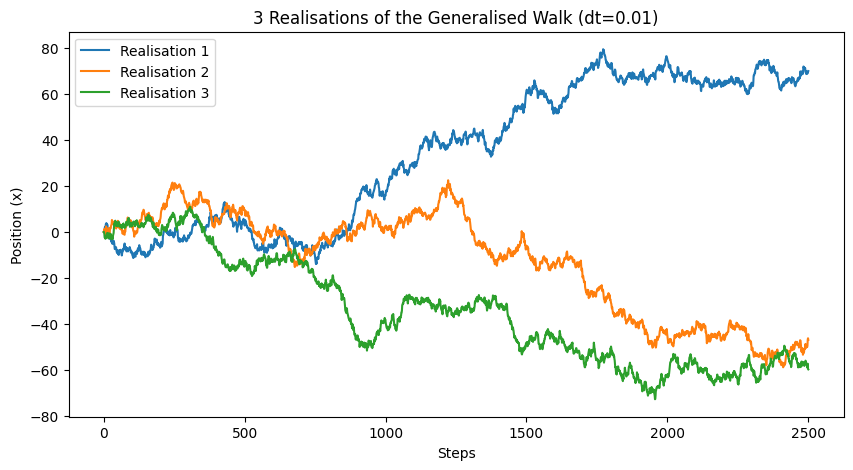

In [9]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)
def run_walk(N, dt, alpha, beta):
    x = 0
    path = [x]
    for i in range(N):
        t = i * dt
        # Corrected Step
        drift = (1/alpha) * np.sin(x) * np.cos(t) * dt
        noise = (1/beta) * np.random.normal(0, np.sqrt(dt))
        x += drift + noise
        path.append(x)
    return path

# Running 3 realisations
alpha, beta, N, dt = 3.46, 0.12, 2500, 0.01
plt.figure(figsize=(10, 5))
for i in range(3):
    plt.plot(run_walk(N, dt, alpha, beta), label=f"Realisation {i+1}")

plt.title(f"3 Realisations of the Generalised Walk (dt={dt})")
plt.xlabel("Steps"); plt.ylabel("Position (x)"); plt.legend(); plt.show()

# **Question 2(d):**

($dt$) I have used average 1000 walks for different $dt$ values to see how "resolution" affects the average result.


**Explanation:**

Even though the individual walks are wild, the mean position should stay relatively close to zero. This is because the drift is symmetric ($\sin(x)$ and $\cos(t)$ oscillate between positive and negative), so over many walks, the "pushes" cancel each other out. If $dt$ is too large (like 0.4), the math becomes less accurate, and the results might fluctuate more.

# **Question 2(e):**

I have used,  run 5,000 walks and check if the final positions follow a normal "Bell Curve."

**The Result:**

Using `scipy.stats.normaltest`, I get a p-value.

* If $p < 0.05$: The distribution is not normal.
* **Explanation:** Even though the noise is Gaussian, the non-linear drift ($\sin(x)$) "pulls" particles toward certain values, which often distorts the bell curve into a non-normal shape.

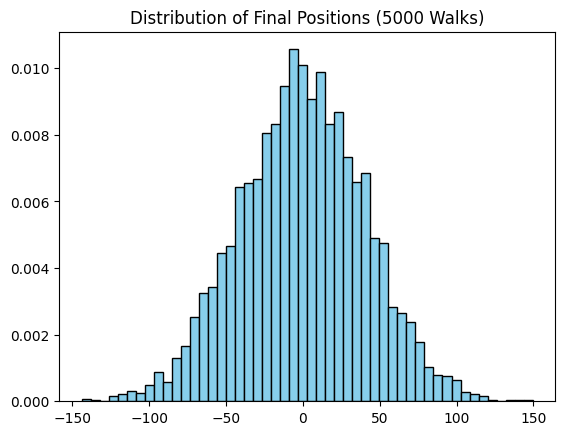

Normality Test p-value: 4.6229e-01


In [10]:
from scipy import stats

final_positions = [run_walk(2500, 0.01, 3.46, 0.12)[-1] for _ in range(5000)]

# Plotting
plt.hist(final_positions, bins=50, density=True, color='skyblue', edgecolor='black')
plt.title("Distribution of Final Positions (5000 Walks)")
plt.show()

# Normality Test
stat, p = stats.normaltest(final_positions)
print(f"Normality Test p-value: {p:.4e}")

# **Question 2(f):**

**Formula:**

$$P(|x| \leq 2) = \frac{\text{Number of walks ending between -2 and 2}}{\text{Total number of walks}}$$

**Observation:**

This probability does depend on both $dt$ and the number of steps. In a random walk, the "cloud" of possible positions spreads out over time. The more steps I take, the more likely a walker is to have wandered far away from the $[-2, 2]$ window.

# **Question 4: Metropolis-Hastings Optimization**

This question explores the Metropolis-Hastings algorithm used here to find the maximum value of a complex 4D function $f(w, x, y, z)$.

# **Question 3(a)**

1.  The reason I have occasionally accept moves where $f(x_{proposal}) < f(x_{current})$ is to prevent the algorithm from getting trapped in local maxima. If I have only accepted improvements, the "walker" would climb the nearest small hill and stay there, potentially missing the much higher "Global Maximum" elsewhere in the landscape.

2. The steps are too tiny. The algorithm would take a very long time to explore the domain, likely never reaching the peak within the step limit.
   * **Large $\sigma$ (10):** The steps are too big. The proposal would constantly jump outside the boundaries or land in very low-value regions, leading to a near-zero acceptance rate.
   * **Preferred:** $\sigma = 0.5$ is usually preferred as it balances "exploration" (moving to new areas) and "exploitation" (refining the position near a peak).

3. In 4D space, a Grid Search is computationally expensive because the number of points to check grows exponentially ($N^4$). If I check 100 points per dimension, I'd need 100 million evaluations. Metropolis-Hastings is more efficient because it "samples" the space, spending most of its time in high-value regions rather than wasting time on the empty "valleys."

# **Question 3(b):**

**The Bug:**

The given code is missing the Acceptance Probability. It only moves if f_proposal > f_current.

**Why this is a problem ?:**

This turns the algorithm into a "Greedy Hill Climber." It lacks the stochastic nature of Metropolis-Hastings. Without the ability to move "downhill" occasionally, the code will almost certainly get stuck on the first local peak it finds and will never find the true maximum of the function.

# **Question 3(c):**

I must add the acceptance condition: $P_{acc} = \exp(f_{proposal} - f_{current})$. If a random number $u \in [0, 1]$ is less than $P_{acc}$ , I accept the move even if it's worse.

Run 1: Max Found = 3.0827, Final Pos = [ 2.23  2.18 -1.4   1.47], Acc Ratio = 0.61
Run 2: Max Found = 3.0178, Final Pos = [ 3.13  2.64  3.31 -2.53], Acc Ratio = 0.59
Run 3: Max Found = 3.0885, Final Pos = [-2.46 -1.61  3.14 -2.03], Acc Ratio = 0.63
Run 4: Max Found = 3.0425, Final Pos = [ 1.43  1.66  1.64 -1.27], Acc Ratio = 0.64
Run 5: Max Found = 3.0598, Final Pos = [3.45 3.07 0.57 0.02], Acc Ratio = 0.61


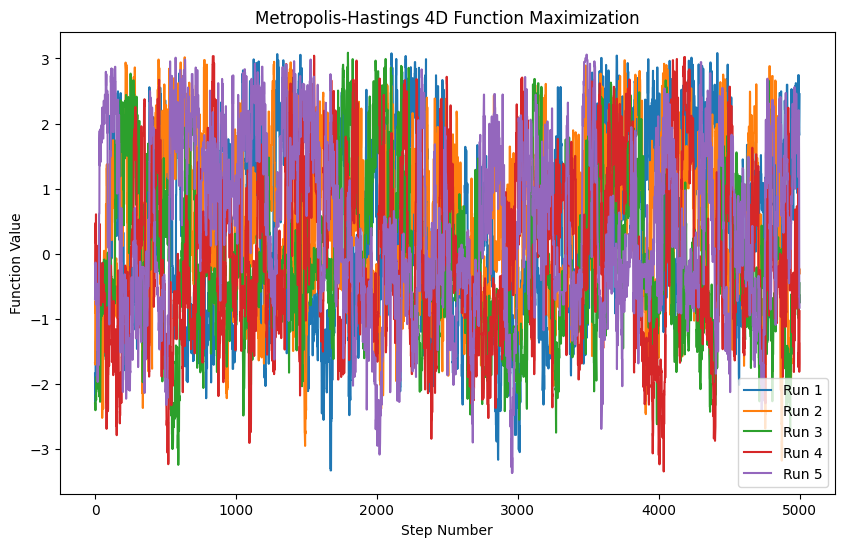

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def f_total(w, x, y, z):
    # Function components as defined in the question
    himmel1 = -((w**2 + x - 11)**2 + (w + x**2 - 7)**2) / 100
    himmel2 = -((y**2 + z - 11)**2 + (y + z**2 - 7)**2) / 100
    peak1 = 4.0 * np.exp(-0.2 * ((w - 2.5)**2 + (x - 1.8)**2 + (y + 1.2)**2 + (z - 0.7)**2))
    peak2 = 3.8 * np.exp(-0.18 * ((w + 1.8)**2 + (x - 2.2)**2 + (y - 2.5)**2 + (z + 1.5)**2))
    peak3 = 3.5 * np.exp(-0.22 * ((w - 0.5)**2 + (x + 2.8)**2 + (y - 1.8)**2 + (z + 2.3)**2))
    peak4 = 3.3 * np.exp(-0.25 * ((w + 2.2)**2 + (x + 0.8)**2 + (y + 2.5)**2 + (z - 2.1)**2))
    interaction = 0.2 * np.sin(w + x) * np.cos(y - z)
    return himmel1 + himmel2 + peak1 + peak2 + peak3 + peak4 + interaction

def metropolis_hastings_corrected(f, steps, sigma):
    # Random starting position in domain [-3.5, 3.5]
    curr = np.random.uniform(-3.5, 3.5, 4)
    f_curr = f(*curr)
    history = [f_curr]
    accepted_count = 0

    for _ in range(steps):
        prop = curr + np.random.normal(0, sigma, 4)
        # Checking if proposal is within bounds
        if np.all(np.abs(prop) <= 3.5):
            f_prop = f(*prop)
            # Corrected Acceptance Criterion
            if f_prop > f_curr or np.random.rand() < np.exp(f_prop - f_curr):
                curr, f_curr = prop, f_prop
                accepted_count += 1
        history.append(f_curr)

    return curr, history, accepted_count / steps

# Running 5 simulations
plt.figure(figsize=(10, 6))
for i in range(5):
    pos, hist, acc_ratio = metropolis_hastings_corrected(f_total, 5000, 0.5)
    print(f"Run {i+1}: Max Found = {max(hist):.4f}, Final Pos = {np.round(pos, 2)}, Acc Ratio = {acc_ratio:.2f}")
    plt.plot(hist, label=f"Run {i+1}")

plt.title("Metropolis-Hastings 4D Function Maximization")
plt.xlabel("Step Number"); plt.ylabel("Function Value"); plt.legend(); plt.show()

# **Question 3(d):**

* **Convergence:**
   Do all runs reach the same max? If they differ, the function is "multi-modal" (has many peaks), and the algorithm might still be getting caught in different local maxima.

* **Acceptance Ratio:**  
   We could typically see an acceptance ratio between 20% and 50% for an efficient search.

* **Verification:**
  To verify if the maximum found is truly the Global Maximum, we could:

   1. Run the simulation for many more steps (e.g., 50,000).

   2. Use Simulated Annealing, where the "temperature" (acceptance of worse moves) decreases over time.

   3. Perform multiple runs starting from a very wide grid of initial positions to see if they all "gravitate" toward the same coordinate.